# 03 Cropped group-centroid analysis

这个 notebook 承接 `01_Findatom.ipynb` 保存的 active session，专门执行裁剪区域内的 class group 几何中心和 group-pair 位移分析。

流程是：读取 01 的原子位置和分类；在原图上选择一个 crop ROI；按 crop ROI 外接矩形裁剪图像，并只保留 ROI 内原子；在裁剪图上选择 measurement ROI；计算每个 ROI 内各 class group 的无权重几何中心、间距和角度；最后输出只包含几何中心、箭头、group legend 和真实 nm scalebar 的正式图。

In [79]:
from __future__ import annotations

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src' / 'em_atom_workbench').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROJECT_SRC = str(PROJECT_ROOT / 'src')
if PROJECT_SRC in sys.path:
    sys.path.remove(PROJECT_SRC)
sys.path.insert(0, PROJECT_SRC)
for module_name in list(sys.modules):
    if module_name == 'em_atom_workbench' or module_name.startswith('em_atom_workbench.'):
        del sys.modules[module_name]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from em_atom_workbench import (
    AnalysisROI,
    FigureStyleConfig,
    add_crop_coordinate_columns_to_group_results,
    assign_points_to_rois,
    compute_group_centroids_by_roi,
    compute_group_pair_displacements,
    crop_image_and_points_by_roi,
    full_image_roi,
    pick_rois_on_image_with_napari,
    pick_rois_with_napari,
    plot_charge_center_displacement_map,
    summarize_rois_and_points,
    transform_rois_xy,
    initialize_analysis_workspace,
)
from em_atom_workbench.notebook_workflows import (
    cropped_group_centroid_output_dirs,
    export_cropped_group_centroid_excel,
    export_notebook03_results,
    initialize_simple_quant_v2_analysis,
)

FIG_STYLE = FigureStyleConfig()
plt.rcParams['figure.dpi'] = 140
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False


def rois_to_table(local_rois, global_rois=None):
    global_rois = global_rois or local_rois
    rows = []
    for local_roi, global_roi in zip(local_rois, global_rois, strict=False):
        rows.append({
            'roi_id': local_roi.roi_id,
            'roi_name': local_roi.roi_name or local_roi.roi_id,
            'roi_color': local_roi.color,
            'polygon_local_xy_px': local_roi.polygon_xy_px,
            'polygon_global_xy_px': global_roi.polygon_xy_px,
            'enabled': bool(local_roi.enabled),
        })
    return pd.DataFrame(rows)

In [64]:
CROP_ROI_REUSE = CROP_ROI
MEASUREMENT_ROIS_REUSE = MEASUREMENT_ROIS

CENTER_GROUPS_REUSE = center_groups
CENTER_PAIRS_REUSE = center_pairs
CENTER_GROUP_CLASS_WEIGHTS_REUSE = CENTER_GROUP_CLASS_WEIGHTS
CENTER_GROUP_WEIGHT_COLUMNS_REUSE = CENTER_GROUP_WEIGHT_COLUMNS

## 0. Workspace parameters

这一格只定义当前 dataset/run 的统一 workspace。03 默认从 `workspace/state/sessions/01_final_curated.pkl` 读取 01 的最终 curated session，并把所有 03 输出写入 canonical `03_group_centroid/`。

In [82]:
OUTPUT_ROOT = PROJECT_ROOT / 'results'
DATASET_ID = '2'
ANALYSIS_ID = 'fix'

workspace = initialize_analysis_workspace(
    output_root=OUTPUT_ROOT,
    dataset_id=DATASET_ID,
    analysis_id=ANALYSIS_ID,
)

# 为兼容旧 wrapper，RESULT_ROOT 仍然存在；新流程中它指向当前 workspace.root。
RESULT_ROOT = workspace.root

# SESSION_SOURCE='01_final_curated' 是推荐默认入口：
# workspace/state/sessions/01_final_curated.pkl
SESSION_SOURCE = '01_final_curated'

# SESSION_PATH=None 时读取 SESSION_SOURCE。
# 如需读取旧 results/_active_session.pkl 或手动 checkpoint，可在这里填 pickle 路径。
SESSION_PATH = None

print(f'workspace: {workspace.root}')
print(f'default session: {workspace.sessions_dir / (SESSION_SOURCE + ".pkl")}')

workspace: d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\2\fix
default session: d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\2\fix\state\sessions\01_final_curated.pkl


In [83]:
# SOURCE_TABLE：选择 01 产生的哪一张原子坐标表作为分析起点。
# curated：正式定量推荐；refined：检查精修点；candidate：通常仅用于诊断。
SOURCE_TABLE = 'refined'
USE_KEEP_ONLY = True
IMAGE_CHANNEL = None
IMAGE_KEY = 'raw'

context = initialize_simple_quant_v2_analysis(
    session_path=SESSION_PATH,
    workspace=workspace,
    session_source=SESSION_SOURCE,
    required_stage=None,
    result_root=RESULT_ROOT,
    source_table=SOURCE_TABLE,
    use_keep_only=USE_KEEP_ONLY,
    class_filter=None,
    class_id_filter=None,
    rois=None,
    image_channel=IMAGE_CHANNEL,
    image_key=IMAGE_KEY,
)
session = context['session']
image = context['image']
image_channel = context['image_channel']
analysis_points_global = context['analysis_points']
PIXEL_TO_NM = analysis_points_global.attrs.get('pixel_to_nm')
if PIXEL_TO_NM is None or not np.isfinite(float(PIXEL_TO_NM)) or float(PIXEL_TO_NM) <= 0:
    raise ValueError('03 requires a valid pixel calibration from 01 so the final figure can include a true nm scalebar.')

output_dirs = cropped_group_centroid_output_dirs(workspace=workspace)
preview_figures = {}
figures = {}
excel_exports = {}

display(context['summary_tables']['simple_quant_v2_summary'])
display(context['summary_tables']['analysis_points_preview'])
display(summarize_rois_and_points(analysis_points_global))

,field,value
0,session_name,2
1,current_stage,curated
2,primary_channel,Ptycho_DW1
3,source_table,refined
4,analysis_point_rows,3570
5,unique_points,3570
6,roi_count,1
7,output_dir,d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Pytho...


,atom_id,point_id,source_type,point_set,parent_source_point_id,parent_target_point_id,parent_source_atom_id,parent_target_atom_id,x_px,y_px,...,column_role,keep,quality_score,source_table,x_nm,y_nm,roi_id,roi_name,roi_color,scope_id
0,1986,atom:1986,atom,atoms,<NA>,<NA>,<NA>,<NA>,616.992712,101.962087,...,atom_column,True,0.413112,refined,9.579346,1.583050,global,global,#ff9f1c,global:atoms:refined
1,2479,atom:2479,atom,atoms,<NA>,<NA>,<NA>,<NA>,612.745171,105.996596,...,atom_column,True,0.413112,refined,9.513399,1.645689,global,global,#ff9f1c,global:atoms:refined
2,2005,atom:2005,atom,atoms,<NA>,<NA>,<NA>,<NA>,663.826353,101.242273,...,atom_column,True,0.452403,refined,10.306479,1.571874,global,global,#ff9f1c,global:atoms:refined
3,2742,atom:2742,atom,atoms,<NA>,<NA>,<NA>,<NA>,660.596418,105.157796,...,atom_column,True,0.452403,refined,10.256331,1.632666,global,global,#ff9f1c,global:atoms:refined
4,2073,atom:2073,atom,atoms,<NA>,<NA>,<NA>,<NA>,77.916986,527.976228,...,atom_column,True,0.341729,refined,1.209729,8.197288,global,global,#ff9f1c,global:atoms:refined


,roi_id,roi_name,point_rows,unique_point_count,unique_atom_count,point_set_count,class_count
0,global,global,3570,3570,3570,1,3


## 1. Crop ROI on the original image

打开 napari 后在原图上画 crop ROI。若 ROI 是四角矩形，即使它有旋转，03 也会严格按矩形形状采样裁剪，并把长边旋转到水平方向；其他 polygon ROI 会保留 polygon 内原子并按外接矩形裁剪。后续计算和展示使用裁剪后的局部坐标，并在导出表中保留 global 坐标。

In [84]:
OPEN_CROP_ROI_PICKER = False

# 手动模式示例：
# CROP_ROI = AnalysisROI(
#     roi_id='crop_1',
#     roi_name='crop_1',
#     polygon_xy_px=((100, 100), (300, 100), (300, 260), (100, 260)),
# )
CROP_ROI = CROP_ROI_REUSE #None
CROP_ROI_PREFIX = 'Crop'
CROP_MARGIN_PX = 0

if OPEN_CROP_ROI_PICKER:
    picked_crop_rois = pick_rois_with_napari(
        session,
        analysis_points_global,
        image_channel=image_channel,
        image_key=IMAGE_KEY,
        default_roi_prefix=CROP_ROI_PREFIX,
        start_index=1,
    )
    CROP_ROI = picked_crop_rois[0]
elif CROP_ROI is None:
    CROP_ROI = full_image_roi(image, roi_id='crop_1', roi_name='crop_full')

crop_result = crop_image_and_points_by_roi(
    image,
    analysis_points_global,
    CROP_ROI,
    margin_px=CROP_MARGIN_PX,
    crop_id='crop_1',
    crop_name=CROP_ROI.roi_name or CROP_ROI.roi_id,
)
cropped_image = crop_result['image']
cropped_background_image = cropped_image.copy() if hasattr(cropped_image, 'copy') else np.array(cropped_image, copy=True)
cropped_atom_table = crop_result['points']
crop_table = crop_result['crop_table']
crop_origin_xy_px = crop_result['origin_xy_px']
crop_basis_x_px = crop_result['basis_x_px']
crop_basis_y_px = crop_result['basis_y_px']

display(crop_table)
display(cropped_atom_table.head())
display(summarize_rois_and_points(cropped_atom_table))

,crop_id,crop_name,source_roi_id,source_roi_name,crop_mode,origin_x_px,origin_y_px,basis_x_x,basis_x_y,basis_y_x,...,y_min_px,y_max_px,width_px,height_px,pixel_to_nm,width_nm,height_nm,polygon_xy_px,polygon_local_xy_px,point_count
0,crop_1,Crop_1,roi_1,Crop_1,oriented_rectangle,7.246922,8.907453,0.999834,-0.018227,0.018227,...,0.0,648.0,663.518323,638.666667,0.015526,10.301696,9.915853,"((22.89869499206543, 8.622116088867188), (18.8...","((15.654373502370142, 0.0), (0.0, 638.66666701...",3570


,atom_id,point_id,source_type,point_set,parent_source_point_id,parent_target_point_id,parent_source_atom_id,parent_target_atom_id,x_px,y_px,...,crop_id,crop_name,crop_origin_x_px,crop_origin_y_px,crop_basis_x_x,crop_basis_x_y,crop_basis_y_x,crop_basis_y_y,crop_width_px,crop_height_px
0,1986,atom:1986,atom,atoms,<NA>,<NA>,<NA>,<NA>,607.948361,104.153174,...,crop_1,Crop_1,7.246922,8.907453,0.999834,-0.018227,0.018227,0.999834,663.518323,638.666667
1,2479,atom:2479,atom,atoms,<NA>,<NA>,<NA>,<NA>,603.627987,108.109592,...,crop_1,Crop_1,7.246922,8.907453,0.999834,-0.018227,0.018227,0.999834,663.518323,638.666667
2,2005,atom:2005,atom,atoms,<NA>,<NA>,<NA>,<NA>,654.787341,104.287129,...,crop_1,Crop_1,7.246922,8.907453,0.999834,-0.018227,0.018227,0.999834,663.518323,638.666667
3,2742,atom:2742,atom,atoms,<NA>,<NA>,<NA>,<NA>,651.486574,108.143128,...,crop_1,Crop_1,7.246922,8.907453,0.999834,-0.018227,0.018227,0.999834,663.518323,638.666667
4,2073,atom:2073,atom,atoms,<NA>,<NA>,<NA>,<NA>,61.197119,520.270665,...,crop_1,Crop_1,7.246922,8.907453,0.999834,-0.018227,0.018227,0.999834,663.518323,638.666667


,roi_id,roi_name,point_rows,unique_point_count,unique_atom_count,point_set_count,class_count
0,global,global,3570,3570,3570,1,3


## 2. Measurement ROIs on the cropped image

这里在裁剪图上选择用于几何中心计算的 ROI。坐标是 crop-local px；导出时会同时保存这些 ROI 的 local/global polygon。若没有选择 ROI，则默认使用整个裁剪图。

In [85]:
OPEN_MEASUREMENT_ROI_PICKER = False
MEASUREMENT_ROIS = None
MEASUREMENT_ROI_PREFIX = 'Measure_ROI'

if OPEN_MEASUREMENT_ROI_PICKER:
    MEASUREMENT_ROIS = pick_rois_on_image_with_napari(
        cropped_background_image,
        cropped_atom_table,
        default_roi_prefix=MEASUREMENT_ROI_PREFIX,
        start_index=1,
        title='03 measurement ROI picker',
    )
if not MEASUREMENT_ROIS:
    MEASUREMENT_ROIS = MEASUREMENT_ROIS_REUSE #[full_image_roi(cropped_background_image, roi_id='crop_full', roi_name='crop_full')]

# 重新分配 measurement ROI 前，移除 crop/global ROI 标记，避免 scope_id 沿用上一步。
measurement_source_points = cropped_atom_table.drop(columns=['roi_id', 'roi_name', 'roi_color', 'scope_id'], errors='ignore')
measurement_points = assign_points_to_rois(measurement_source_points, MEASUREMENT_ROIS)
measurement_points.attrs['pixel_to_nm'] = PIXEL_TO_NM
measurement_rois_global = transform_rois_xy(
    MEASUREMENT_ROIS,
    origin_xy_px=crop_origin_xy_px,
    basis_x_px=crop_basis_x_px,
    basis_y_px=crop_basis_y_px,
)
measurement_roi_table = rois_to_table(MEASUREMENT_ROIS, measurement_rois_global)

display(measurement_roi_table)
display(summarize_rois_and_points(measurement_points, rois=MEASUREMENT_ROIS))

,roi_id,roi_name,roi_color,polygon_local_xy_px,polygon_global_xy_px,enabled
0,roi_1,Measure_ROI_1,#1f77b4,"((4.811186790466309, 307.31866455078125), (5.9...","((17.658888598342035, 316.0873673097184), (19....",True
1,roi_2,Measure_ROI_2,#ff7f0e,"((49.62009811401367, 307.0314025878906), (50.7...","((62.45511979915143, 314.9834091400011), (64.3...",True
2,roi_3,Measure_ROI_3,#2ca02c,"((96.75701141357422, 307.0185852050781), (95.8...","((109.58396859832528, 314.1114168463431), (109...",True
3,roi_4,Measure_ROI_4,#d62728,"((143.5412139892578, 308.36248779296875), (143...","((156.38489456490427, 314.60234808300714), (15...",True
4,roi_5,Measure_ROI_5,#9467bd,"((188.28927612304688, 308.06964111328125), (18...","((201.12018489073938, 313.49391523863005), (20...",True
...,...,...,...,...,...,...
177,roi_178,Measure_ROI_178,#7f7f7f,"((246.15101623535156, 15.54001522064209), (244...","((253.64029720969165, 19.958226104044606), (25...",True
178,roi_179,Measure_ROI_179,#bcbd22,"((153.9697265625, 16.440715789794922), (151.09...","((161.4907389604585, 22.538989893432678), (159...",True
179,roi_180,Measure_ROI_180,#17becf,"((106.84300231933594, 14.970915794372559), (10...","((114.34505346417212, 21.928425398045256), (11...",True
180,roi_181,Measure_ROI_181,#1f77b4,"((62.34854507446289, 15.469810485839844), (59....","((69.86708158761536, 23.23824949968422), (67.5...",True


,roi_id,roi_name,point_rows,unique_point_count,unique_atom_count,point_set_count,class_count
0,roi_1,Measure_ROI_1,12,12,12,1,2
1,roi_2,Measure_ROI_2,12,12,12,1,2
2,roi_3,Measure_ROI_3,12,12,12,1,2
3,roi_4,Measure_ROI_4,12,12,12,1,2
4,roi_5,Measure_ROI_5,12,12,12,1,2
...,...,...,...,...,...,...,...
177,roi_178,Measure_ROI_178,20,20,20,1,3
178,roi_179,Measure_ROI_179,20,20,20,1,3
179,roi_180,Measure_ROI_180,20,20,20,1,3
180,roi_181,Measure_ROI_181,20,20,20,1,3


## 3. Configure class groups and center pairs

每个 group 可以包含一个或多个 `class_id`。默认几何中心是 ROI 内该 group 所有原子的无权重平均中心；如需加权，可设置每个 group 的 class 权重或权重列。`center_pairs` 的方向约定是 `group_A -> group_B`。

In [37]:
center_groups = {
     'group_A': [2],
     'group_B': [0, 1],
}

center_pairs = [
    ('group_A', 'group_B'),
]

MIN_POINTS_PER_GROUP = 1

# 可选：按 class_id 加权。未列出的 class_id 权重默认为 1.0。
# 写法 1：dict，适合 group 内 class_id 权重不连续或需要显式标注。
# 写法 2：list/tuple，顺序必须和 center_groups[group_name] 一致。
CENTER_GROUP_CLASS_WEIGHTS = {
     'group_A': {2: 2.0},
     'group_B': {0: 1.0, 1: 2.0},
    # 'group_B': [1.0, 2.0],
}

# 可选：按表格中的数值列加权，例如 'quality_score'。
# 可以写成全局字符串，也可以按 group 分别指定列名。
CENTER_GROUP_WEIGHT_COLUMNS = {
    # 'group_A': 'quality_score',
    # 'group_B': 'quality_score',
}

group_config_table = pd.DataFrame([
    {
        'group_name': key,
        'class_ids': ','.join(str(value) for value in values),
        'class_weights': CENTER_GROUP_CLASS_WEIGHTS.get(key, ''),
        'weight_column': CENTER_GROUP_WEIGHT_COLUMNS.get(key, '') if isinstance(CENTER_GROUP_WEIGHT_COLUMNS, dict) else CENTER_GROUP_WEIGHT_COLUMNS,
    }
    for key, values in center_groups.items()
])
display(group_config_table)

,group_name,class_ids,class_weights,weight_column
0,group_A,2,{2: 2.0},
1,group_B,"0,1","{0: 1.0, 1: 2.0}",


## 4. Compute group centroids / displacements

这个 cell 复用 02 的几何中心逻辑，但结果表额外加入 crop-local/global px 坐标和 nm 坐标，以及 `dx_nm`、`dy_nm`、`distance_nm`。

In [86]:
group_centroid_table_raw = compute_group_centroids_by_roi(
    measurement_points,
    center_groups=center_groups,
    center_group_class_weights=CENTER_GROUP_CLASS_WEIGHTS,
    center_group_weight_columns=CENTER_GROUP_WEIGHT_COLUMNS,
    min_points=MIN_POINTS_PER_GROUP,
)
group_displacement_table_raw = compute_group_pair_displacements(
    group_centroid_table_raw,
    center_pairs=center_pairs,
    pixel_to_nm=PIXEL_TO_NM,
)
group_centroid_table, group_displacement_table = add_crop_coordinate_columns_to_group_results(
    group_centroid_table_raw,
    group_displacement_table_raw,
    crop_origin_xy_px=crop_origin_xy_px,
    crop_basis_x_px=crop_basis_x_px,
    crop_basis_y_px=crop_basis_y_px,
    pixel_to_nm=PIXEL_TO_NM,
)

summary = pd.DataFrame([
    {'metric': 'crop_point_count', 'value': len(cropped_atom_table)},
    {'metric': 'measurement_roi_count', 'value': len(MEASUREMENT_ROIS)},
    {'metric': 'group_count', 'value': len(center_groups)},
    {'metric': 'center_pair_count', 'value': len(center_pairs)},
    {'metric': 'pixel_to_nm', 'value': PIXEL_TO_NM},
])

display(group_centroid_table)
display(group_displacement_table)
display(summary)

,roi_id,roi_name,group_name,class_ids,n_points,center_x,center_y,center_x_std,center_y_std,weight_mode,...,valid,invalid_reason,center_x_local_px,center_y_local_px,center_x_global_px,center_y_global_px,center_x_local_nm,center_y_local_nm,center_x_global_nm,center_y_global_nm
0,roi_1,Measure_ROI_1,group_A,2,6,28.776012,325.150396,12.899931,9.657721,class,...,True,,28.776012,325.150396,41.944756,333.479323,0.446772,5.048241,0.651229,5.177555
1,roi_1,Measure_ROI_1,group_B,"0,1",6,25.137492,325.181779,13.532243,9.872696,class,...,True,,25.137492,325.181779,38.307413,333.577021,0.390281,5.048729,0.594756,5.179072
2,roi_2,Measure_ROI_2,group_A,2,6,75.198881,325.467935,12.762575,9.758314,class,...,True,,75.198881,325.467935,88.365701,332.950647,1.167528,5.053171,1.371954,5.169347
3,roi_2,Measure_ROI_2,group_B,"0,1",6,71.509421,325.525459,13.450633,10.013293,class,...,True,,71.509421,325.525459,84.677902,333.075411,1.110246,5.054064,1.314698,5.171284
4,roi_3,Measure_ROI_3,group_A,2,6,121.473454,325.534030,12.706771,9.627905,class,...,True,,121.473454,325.534030,134.633790,332.173272,1.885980,5.054198,2.090306,5.157278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,roi_180,Measure_ROI_180,group_B,"0,1",12,130.457106,37.986265,12.802230,13.764373,class,...,True,,130.457106,37.986265,138.374741,44.509530,2.025459,0.589770,2.148388,0.691049
360,roi_181,Measure_ROI_181,group_A,2,8,84.265064,37.898759,12.706284,13.321538,class,...,True,,84.265064,37.898759,92.188778,45.263994,1.308288,0.588411,1.431311,0.702763
361,roi_181,Measure_ROI_181,group_B,"0,1",12,84.313861,37.746779,12.912994,13.892092,class,...,True,,84.313861,37.746779,92.234797,45.111149,1.309046,0.586051,1.432025,0.700390
362,roi_182,Measure_ROI_182,group_A,2,8,37.801723,37.740479,12.788587,13.331824,class,...,True,,37.801723,37.740479,45.730271,45.952640,0.586904,0.585954,0.710002,0.713454


,roi_id,roi_name,group_A,group_B,center_A_x,center_A_y,center_B_x,center_B_y,dx_px,dy_px,...,center_B_y_global_px,center_B_x_local_nm,center_B_y_local_nm,center_B_x_global_nm,center_B_y_global_nm,dx_local_px,dy_local_px,dx_nm,dy_nm,distance_nm
0,roi_1,Measure_ROI_1,group_A,group_B,28.776012,325.150396,25.137492,325.181779,-3.638520,0.031382,...,333.577021,0.390281,5.048729,0.594756,5.179072,-3.638520,0.031382,-0.056491,0.000487,0.056493
1,roi_2,Measure_ROI_2,group_A,group_B,75.198881,325.467935,71.509421,325.525459,-3.689460,0.057525,...,333.075411,1.110246,5.054064,1.314698,5.171284,-3.689460,0.057525,-0.057282,0.000893,0.057289
2,roi_3,Measure_ROI_3,group_A,group_B,121.473454,325.534030,117.898709,325.568204,-3.574744,0.034174,...,332.272599,1.830479,5.054728,2.034824,5.158820,-3.574744,0.034174,-0.055501,0.000531,0.055504
3,roi_4,Measure_ROI_4,group_A,group_B,167.578865,325.693764,164.110716,325.744934,-3.468149,0.051170,...,331.606980,2.547961,5.057472,2.752236,5.148485,-3.468149,0.051170,-0.053846,0.000794,0.053852
4,roi_5,Measure_ROI_5,group_A,group_B,213.745303,325.779666,210.233644,325.776644,-3.511659,-0.003021,...,330.797991,3.264059,5.057964,3.468225,5.135925,-3.511659,-0.003021,-0.054522,-0.000047,0.054522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,roi_178,Measure_ROI_178,group_A,group_B,222.630835,38.398619,222.714090,38.240599,0.083254,-0.158020,...,43.082230,3.457829,0.593718,3.580591,0.668889,0.083254,-0.158020,0.001293,-0.002453,0.002773
178,roi_179,Measure_ROI_179,group_A,group_B,176.605948,38.155827,176.736175,38.015703,0.130228,-0.140124,...,43.695423,2.743982,0.590227,2.866799,0.678409,0.130228,-0.140124,0.002022,-0.002176,0.002970
179,roi_180,Measure_ROI_180,group_A,group_B,130.432113,38.059770,130.457106,37.986265,0.024993,-0.073505,...,44.509530,2.025459,0.589770,2.148388,0.691049,0.024993,-0.073505,0.000388,-0.001141,0.001205
180,roi_181,Measure_ROI_181,group_A,group_B,84.265064,37.898759,84.313861,37.746779,0.048797,-0.151980,...,45.111149,1.309046,0.586051,1.432025,0.700390,0.048797,-0.151980,0.000758,-0.002360,0.002478


,metric,value
0,crop_point_count,3570.000000
1,measurement_roi_count,182.000000
2,group_count,2.000000
3,center_pair_count,1.000000
4,pixel_to_nm,0.015526


## 5. Plot cropped displacement arrows

最终图输出四张裁剪区域图：未叠加原图、纯箭头、纯位移大小色图、箭头+色图。色图按每个 measurement ROI / 原胞的 `group_A -> group_B` 位移大小着色；箭头以 A/B 中点为锚点，方向沿 `group_A -> group_B`，视觉长度可自动放大。

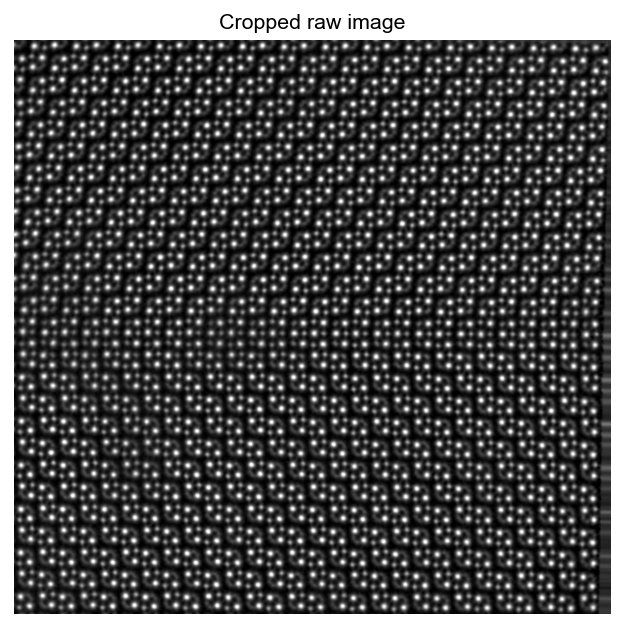

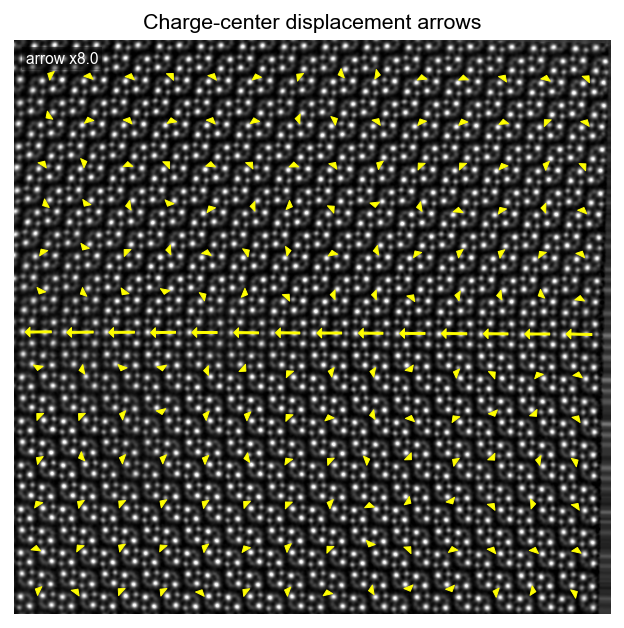

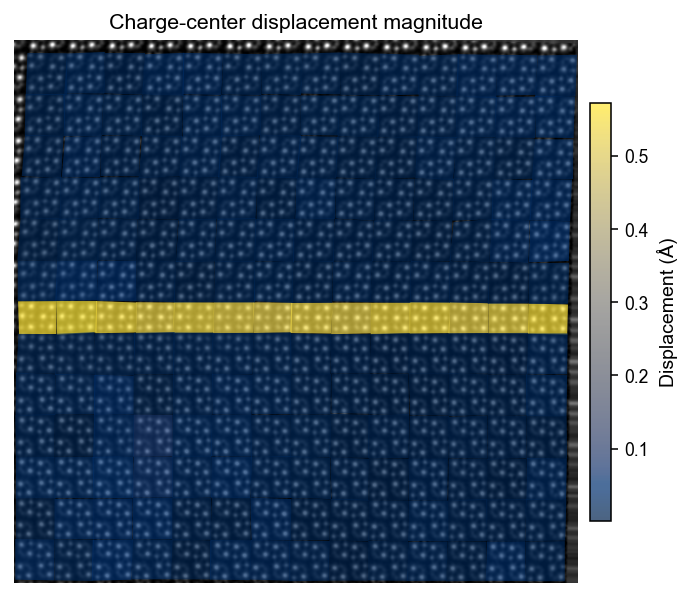

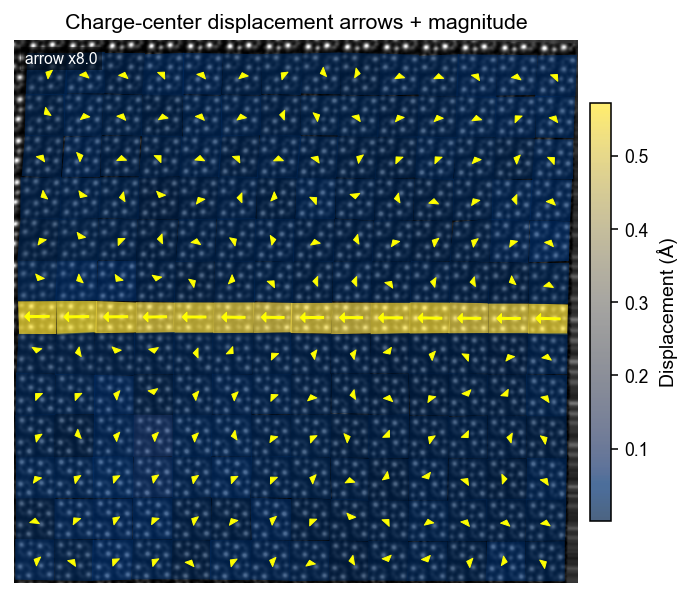

In [101]:
SHOW_SCALEBAR = False          # 03 默认不在图中显示 scalebar。
SCALEBAR_LENGTH_NM = None      # 若 SHOW_SCALEBAR=True，可设置具体 nm 长度；None 自动估计。
SCALEBAR_COLOR = 'white'
SCALEBAR_LINEWIDTH = 1.2
SCALEBAR_LOCATION = 'lower right'

BACKGROUND_CONTRAST_PERCENTILES = (1.0, 99.0)
VECTOR_VALUE_COLUMN = 'distance_A'  # None 时自动优先使用 distance_nm，其次 distance_A / distance_px。
VECTOR_CMAP = 'cividis'
VECTOR_ALPHA = 0.7
SHOW_VECTOR_COLORBAR = True
SHOW_ROI_OUTLINES = False
ROI_OUTLINE_COLOR = '#f5f5f5'
ROI_OUTLINE_LINEWIDTH = 0.65
ROI_OUTLINE_ALPHA = 0.25

ARROW_COLOR = '#ffff00'
ARROW_EDGE_COLOR = '#ffff00'   # 不需要边线时设为 None。
ARROW_LINEWIDTH = 0.5
ARROW_MUTATION_SCALE = 2.5
ARROW_TAIL_WIDTH = 0.4
ARROW_HEAD_WIDTH = 2
ARROW_HEAD_LENGTH = 1
ARROW_ALPHA = 1
VECTOR_SCALE = 8         # 'auto' 会放大小位移，数值则直接作为倍率。
VECTOR_AUTO_TARGET_FRACTION = 0.085
VECTOR_AUTO_MAX_SCALE = 5.0
SHOW_VECTOR_SCALE_LABEL = True

_charge_plot_common = dict(
    image=cropped_background_image,
    measurement_rois=MEASUREMENT_ROIS,
    group_displacement_table=group_displacement_table,
    pixel_to_nm=PIXEL_TO_NM,
    coordinate_space='local',
    style=FIG_STYLE,
    contrast_percentiles=BACKGROUND_CONTRAST_PERCENTILES,
    value_column=VECTOR_VALUE_COLUMN,
    magnitude_cmap=VECTOR_CMAP,
    magnitude_alpha=VECTOR_ALPHA,
    roi_outline_color=ROI_OUTLINE_COLOR,
    roi_outline_linewidth=ROI_OUTLINE_LINEWIDTH,
    roi_outline_alpha=ROI_OUTLINE_ALPHA,
    arrow_color=ARROW_COLOR,
    arrow_edge_color=ARROW_EDGE_COLOR,
    arrow_linewidth=ARROW_LINEWIDTH,
    arrow_mutation_scale=ARROW_MUTATION_SCALE,
    arrow_tail_width=ARROW_TAIL_WIDTH,
    arrow_head_width=ARROW_HEAD_WIDTH,
    arrow_head_length=ARROW_HEAD_LENGTH,
    arrow_alpha=ARROW_ALPHA,
    vector_scale=VECTOR_SCALE,
    vector_auto_target_fraction=VECTOR_AUTO_TARGET_FRACTION,
    vector_auto_max_scale=VECTOR_AUTO_MAX_SCALE,
    show_scalebar=SHOW_SCALEBAR,
    scalebar_length_nm=SCALEBAR_LENGTH_NM,
    scalebar_color=SCALEBAR_COLOR,
    scalebar_linewidth=SCALEBAR_LINEWIDTH,
    scalebar_location=SCALEBAR_LOCATION,
)

fig, ax = plot_charge_center_displacement_map(
    mode='raw',
    title='Cropped raw image',
    show_colorbar=False,
    show_roi_outlines=False,
    show_vector_scale_label=False,
    **_charge_plot_common,
)
figures['cropped_raw_image'] = fig
display(fig)
plt.close(fig)

fig, ax = plot_charge_center_displacement_map(
    mode='arrows',
    title='Charge-center displacement arrows',
    show_colorbar=False,
    show_roi_outlines=SHOW_ROI_OUTLINES,
    show_vector_scale_label=SHOW_VECTOR_SCALE_LABEL,
    **_charge_plot_common,
)
figures['charge_displacement_arrows'] = fig
display(fig)
plt.close(fig)

fig, ax = plot_charge_center_displacement_map(
    mode='magnitude',
    title='Charge-center displacement magnitude',
    show_colorbar=SHOW_VECTOR_COLORBAR,
    show_roi_outlines=SHOW_ROI_OUTLINES,
    show_vector_scale_label=False,
    **_charge_plot_common,
)
figures['charge_displacement_magnitude'] = fig
display(fig)
plt.close(fig)

fig, ax = plot_charge_center_displacement_map(
    mode='combined',
    title='Charge-center displacement arrows + magnitude',
    show_colorbar=SHOW_VECTOR_COLORBAR,
    show_roi_outlines=SHOW_ROI_OUTLINES,
    show_vector_scale_label=SHOW_VECTOR_SCALE_LABEL,
    **_charge_plot_common,
)
figures['charge_displacement_arrows_magnitude'] = fig
display(fig)
plt.close(fig)

## 6. Export Excel

导出裁剪 ROI、裁剪后原子表、measurement ROIs、group centroid、group displacement、group config 和 summary。

In [102]:
cropped_group_excel = export_cropped_group_centroid_excel(
    output_dirs,
    crop_table=crop_table,
    cropped_atom_table=cropped_atom_table,
    measurement_roi_table=measurement_roi_table,
    group_centroid_table=group_centroid_table,
    group_displacement_table=group_displacement_table,
    group_config=group_config_table,
    summary=summary,
)
excel_exports['cropped_group_centroid'] = cropped_group_excel
display(cropped_group_excel)

{'path': 'd:\\LIANGKUAN\\PolyU-PhD\\Reserch\\HfO2\\code\\Python\\atom_analysis_manual\\results\\2\\fix\\03_group_centroid\\tables\\cropped_group_centroid_analysis.xlsx',
 'writer_engine': 'minimal_xlsx',
 'warnings': []}

## 7. Final export manifest

统一保存 CSV 表、正式 figures、config JSON、Excel 记录、session checkpoint 和 manifest。

In [103]:
# =========================
# Final figure export parameters
# =========================
# preview figures 只用于调参检查；默认不保存；若启用则写入 03_group_centroid/figures_preview。
SAVE_PREVIEW_FIGURES = False

# final figures 是正式导出的论文/报告候选图，保存到 03_group_centroid/figures_final。
SAVE_FINAL_FIGURES = True

FIGURE_FORMATS = FIG_STYLE.normalized_formats() if hasattr(FIG_STYLE, 'normalized_formats') else ('pdf', 'png', 'svg')
FIGURE_DPI = FIG_STYLE.fig_dpi
FIGURE_FONT_FAMILY = 'Arial'
FIGURE_FONT_SIZE = 9
FIG_SHOW_TITLE = True
FIG_SHOW_SCALEBAR = SHOW_SCALEBAR

FINAL_FIGURE_SPECS = {
    'cropped_raw_image': {
        'save': True,
        'title': 'Cropped raw image',
        'show_title': FIG_SHOW_TITLE,
        'font_family': FIGURE_FONT_FAMILY,
        'font_size': FIGURE_FONT_SIZE,
        'formats': FIGURE_FORMATS,
        'dpi': FIGURE_DPI,
    },
    'charge_displacement_arrows': {
        'save': True,
        'title': 'Charge-center displacement arrows',
        'show_title': FIG_SHOW_TITLE,
        'font_family': FIGURE_FONT_FAMILY,
        'font_size': FIGURE_FONT_SIZE,
        'formats': FIGURE_FORMATS,
        'dpi': FIGURE_DPI,
    },
    'charge_displacement_magnitude': {
        'save': True,
        'title': 'Charge-center displacement magnitude',
        'show_title': FIG_SHOW_TITLE,
        'font_family': FIGURE_FONT_FAMILY,
        'font_size': FIGURE_FONT_SIZE,
        'formats': FIGURE_FORMATS,
        'dpi': FIGURE_DPI,
    },
    'charge_displacement_arrows_magnitude': {
        'save': True,
        'title': 'Charge-center displacement arrows + magnitude',
        'show_title': FIG_SHOW_TITLE,
        'font_family': FIGURE_FONT_FAMILY,
        'font_size': FIGURE_FONT_SIZE,
        'formats': FIGURE_FORMATS,
        'dpi': FIGURE_DPI,
    },
}

In [104]:
notebook03_tables = {
    'crop_roi': crop_table,
    'cropped_atoms': cropped_atom_table,
    'measurement_rois': measurement_roi_table,
    'group_centroids': group_centroid_table,
    'group_displacements': group_displacement_table,
    'group_config': group_config_table,
    'summary': summary,
}

notebook03_configs = {
    'notebook03_group_centroid_config': {
        'dataset_id': DATASET_ID,
        'analysis_id': ANALYSIS_ID,
        'session_source': SESSION_SOURCE,
        'source_table': SOURCE_TABLE,
        'use_keep_only': USE_KEEP_ONLY,
        'image_channel': image_channel,
        'image_key': IMAGE_KEY,
        'pixel_to_nm': PIXEL_TO_NM,
        'crop_margin_px': CROP_MARGIN_PX,
        'crop_basis_x_px': crop_basis_x_px,
        'crop_basis_y_px': crop_basis_y_px,
        'crop_roi': crop_table.to_dict(orient='records'),
        'measurement_rois': measurement_roi_table.to_dict(orient='records'),
        'center_groups': center_groups,
        'center_group_class_weights': CENTER_GROUP_CLASS_WEIGHTS,
        'center_group_weight_columns': CENTER_GROUP_WEIGHT_COLUMNS,
        'center_pairs': center_pairs,
        'min_points_per_group': MIN_POINTS_PER_GROUP,
        'show_scalebar': SHOW_SCALEBAR,
        'scalebar_color': SCALEBAR_COLOR,
        'scalebar_linewidth': SCALEBAR_LINEWIDTH,
        'scalebar_location': SCALEBAR_LOCATION,
        'background_contrast_percentiles': BACKGROUND_CONTRAST_PERCENTILES,
        'vector_value_column': VECTOR_VALUE_COLUMN,
        'vector_cmap': VECTOR_CMAP,
        'vector_alpha': VECTOR_ALPHA,
        'show_vector_colorbar': SHOW_VECTOR_COLORBAR,
        'show_roi_outlines': SHOW_ROI_OUTLINES,
        'roi_outline_color': ROI_OUTLINE_COLOR,
        'roi_outline_linewidth': ROI_OUTLINE_LINEWIDTH,
        'roi_outline_alpha': ROI_OUTLINE_ALPHA,
        'arrow_color': ARROW_COLOR,
        'arrow_edge_color': ARROW_EDGE_COLOR,
        'arrow_linewidth': ARROW_LINEWIDTH,
        'arrow_mutation_scale': ARROW_MUTATION_SCALE,
        'arrow_tail_width': ARROW_TAIL_WIDTH,
        'arrow_head_width': ARROW_HEAD_WIDTH,
        'arrow_head_length': ARROW_HEAD_LENGTH,
        'arrow_alpha': ARROW_ALPHA,
        'vector_scale': VECTOR_SCALE,
        'vector_auto_target_fraction': VECTOR_AUTO_TARGET_FRACTION,
        'vector_auto_max_scale': VECTOR_AUTO_MAX_SCALE,
        'show_vector_scale_label': SHOW_VECTOR_SCALE_LABEL,
    }
}

manifest = export_notebook03_results(
    session=session,
    output_dirs=output_dirs,
    tables=notebook03_tables,
    figures=figures,
    preview_figures=preview_figures,
    configs=notebook03_configs,
    excel_exports=excel_exports,
    workspace=workspace,
    session_source=SESSION_SOURCE,
    save_preview_figures=SAVE_PREVIEW_FIGURES,
    save_final_figures=SAVE_FINAL_FIGURES,
    final_figure_specs=FINAL_FIGURE_SPECS,
    figure_formats=FIGURE_FORMATS,
    figure_dpi=FIGURE_DPI,
)
display(manifest)

{'workflow': 'cropped_group_centroid_notebook03',
 'stage_name': '03_group_centroid',
 'builder_script': 'scripts/build_03_cropped_group_centroid_notebook.py',
 'notebook_name': '03_Cropped_group_centroid_analysis.ipynb',
 'session_source': '01_final_curated',
 'output_dir': 'd:\\LIANGKUAN\\PolyU-PhD\\Reserch\\HfO2\\code\\Python\\atom_analysis_manual\\results\\2\\fix\\03_group_centroid',
 'tables': {'crop_roi': 'd:\\LIANGKUAN\\PolyU-PhD\\Reserch\\HfO2\\code\\Python\\atom_analysis_manual\\results\\2\\fix\\03_group_centroid\\tables\\crop_roi.csv',
  'cropped_atoms': 'd:\\LIANGKUAN\\PolyU-PhD\\Reserch\\HfO2\\code\\Python\\atom_analysis_manual\\results\\2\\fix\\03_group_centroid\\tables\\cropped_atoms.csv',
  'measurement_rois': 'd:\\LIANGKUAN\\PolyU-PhD\\Reserch\\HfO2\\code\\Python\\atom_analysis_manual\\results\\2\\fix\\03_group_centroid\\tables\\measurement_rois.csv',
  'group_centroids': 'd:\\LIANGKUAN\\PolyU-PhD\\Reserch\\HfO2\\code\\Python\\atom_analysis_manual\\results\\2\\fix\\03_g